In [1]:
import os
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    Qwen3Config,
    Qwen3ForCausalLM,
    Trainer,
    TrainingArguments,
    TrainerCallback
)
import torch
import time


# Don't change this parameter
MAX_TRAINING_TIME_SECONDS = 60 * 2
MAX_LENGTH = 512
INPUT_IDS = 'input_ids'
ATTENTION_MASK = 'attention_mask'
LABELS = 'labels'

# Don't change these parameters
TOKENIZER_NAME = "ai-forever/rugpt3small_based_on_gpt2"
OUTPUT_DIR = "./output_dir"
NUM_SHARDS = 32
VALIDATION_SIZE = 5000


# TODO: Configure training parameters
TRAINING_CONFIG = {
    'output_dir': f'{OUTPUT_DIR}/gpt2-1b-russian',
    'optim': 'adamw_torch_fused',
    'num_train_epochs': 1,
    'per_device_train_batch_size': 4,
    'save_steps': 100,
    'save_total_limit': 2,
    'learning_rate': 5e-5,
    'weight_decay': 0.01,
    'warmup_steps': 200,
    'logging_steps': 1,
    'eval_steps': 100,
    'eval_strategy': 'steps',
    # 'load_best_model_at_end': True,
    'metric_for_best_model': 'eval_loss',
    'bf16': True,
    'tf32': True,
    'gradient_checkpointing': False,
    'gradient_accumulation_steps': 1,
    'dataloader_num_workers': 4,
    'torch_compile': False,
    'report_to': 'none',
    'save_strategy': 'no', # Потому что памяти мало
}

In [ ]:
class TimeoutCallback(TrainerCallback):
    """Callback to stop training after a specified timeout."""
    def __init__(self, timeout_seconds):
        self.timeout_seconds = timeout_seconds
        self.start_time = None
    
    def on_train_begin(self, args, state, control, **kwargs):
        self.start_time = time.time()
    
    def on_step_end(self, args, state, control, **kwargs):
        if self.start_time is not None:
            elapsed = time.time() - self.start_time
            if elapsed > self.timeout_seconds:
                control.should_training_stop = True
                # Include the final weights in best-checkpoint selection.
                control.should_evaluate = True
                control.should_save = False # Потому что мало памяти
                print(f"Training stopped after {elapsed:.2f} seconds")
        return control

In [3]:
from transformers.models.gpt2.tokenization_gpt2_fast import GPT2TokenizerFast
from datasets import Dataset


def prepare_tokenizer() -> GPT2TokenizerFast:
    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
    tokenizer.pad_token = tokenizer.eos_token
    return tokenizer


def tokenize_function(
        examples: dict[list[str]], 
        tokenizer: GPT2TokenizerFast
    ) -> dict[str, list[int]]:
    """
    TODO: Implement tokenization function.
    - Tokenize the text with truncation and padding to MAX_LENGT
    - Create labels from input_ids
    - Return dictionary with 'labels', 'input_ids', and 'attention_mask'
    """
    tokens = tokenizer(
        examples['text'],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )
    tokens["labels"] = [seq.copy() for seq in tokens["input_ids"]]
    return tokens
    


def save_as_parquets(
    ds: Dataset,
    output_dir: str = OUTPUT_DIR,
    num_shards: int = NUM_SHARDS,
) -> None:
    os.makedirs(output_dir, exist_ok=True)

    for i in range(num_shards):
        shard = ds.shard(num_shards=num_shards, index=i)
        shard.to_parquet(f"{output_dir}/{i:05d}.parquet")


def prepare_dataset() -> None:
    if os.path.exists(OUTPUT_DIR):
        parquet_files = [
            f for f in os.listdir(OUTPUT_DIR)
            if f.endswith(".parquet")
        ]

        if len(parquet_files) == NUM_SHARDS:
            return

    tokenizer = prepare_tokenizer()

    dataset: Dataset = load_dataset(
        "wikimedia/wikipedia",
        "20231101.ru",
        split="train",
    )

    tokenized_dataset = dataset.map(
        tokenize_function,
        batched=True,
        fn_kwargs={"tokenizer": tokenizer},
        remove_columns=dataset.column_names,
    )

    save_as_parquets(tokenized_dataset)


def load_tokenized_dataset(
    data_dir: str = OUTPUT_DIR,
) -> Dataset:
    parquet_files = sorted(
        os.path.join(data_dir, f)
        for f in os.listdir(data_dir)
        if f.endswith(".parquet")
    )

    dataset = load_dataset(
        "parquet",
        data_files=parquet_files,
    )

    return dataset["train"]


def split_dataset(
    dataset: Dataset,
    validation_size: int = VALIDATION_SIZE,
) -> tuple[Dataset, Dataset]:
    dataset_size = len(dataset)
    train_dataset = dataset.select(range(validation_size, dataset_size))
    eval_dataset = dataset.select(range(validation_size))
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(eval_dataset)}")
    
    return train_dataset, eval_dataset


def create_model(tokenizer):
    # Don't change this parameter
    MODEL_CONFIG = {
        'hidden_size': 2048,
        'num_hidden_layers': 12,
        'num_attention_heads': 16,
        'num_key_value_heads': 8,
        'intermediate_size': 8192,
        'head_dim': 128,
        'hidden_act': 'silu',
        'initializer_range': 0.02,
        'scale_attn_weights': True,
        'use_cache': True,
    }

    config = Qwen3Config(
        vocab_size=tokenizer.vocab_size,
        bos_token_id=tokenizer.bos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
        **MODEL_CONFIG
    )
    
    model = Qwen3ForCausalLM._from_config(
        config,
        attn_implementation='flash_attention_2',
        torch_dtype=torch.bfloat16
    )
    
    print(f"Model pad token id: {model.config.pad_token_id}")
    
    with torch.no_grad():
        total_params = sum(p.numel() for p in model.parameters())
        print(f"Total params: {total_params:,}")
    
    return model


def train_model() -> None:
    tokenizer = prepare_tokenizer()

    dataset = load_tokenized_dataset()
    train_dataset, eval_dataset = split_dataset(dataset)

    model = create_model(tokenizer)

    training_args = TrainingArguments(
        **TRAINING_CONFIG
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        callbacks=[
            TimeoutCallback(
                timeout_seconds=MAX_TRAINING_TIME_SECONDS
            )
        ],
    )

    trainer.train()

    print("Running final evaluation...")
    eval_results = trainer.evaluate()
    print(f"Final evaluation results: {eval_results}")

    trainer.save_state()





In [4]:
if __name__ == "__main__":
    # Step 1: Prepare the dataset (run once)
    prepare_dataset()
    
    # Step 2: Train the model
    train_model()

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/27 [00:00<?, ?it/s]

Training samples: 1940063
Validation samples: 5000
Model pad token id: 2
Total params: 960,881,664


Step,Training Loss,Validation Loss
100,10.675600,10.333179
200,8.471100,8.494239
280,8.503300,8.385157


Training stopped after 120.05 seconds
Running final evaluation...


Final evaluation results: {'eval_loss': 8.385156631469727, 'eval_runtime': 44.5848, 'eval_samples_per_second': 112.146, 'eval_steps_per_second': 14.018, 'epoch': 0.0005773005426625101}


In [5]:
import json

path = "output_dir/gpt2-1b-russian/trainer_state.json"

with open(path) as f:
    state = json.load(f)

history = state["log_history"]

In [8]:
import json
import matplotlib.pyplot as plt


def plot_train_eval_loss(
    trainer_state_path: str,
    save_path: str | None = None,
) -> None:
    with open(trainer_state_path, "r", encoding="utf-8") as f:
        state = json.load(f)

    history = state["log_history"]

    train_logs = [
        x for x in history
        if "loss" in x and "eval_loss" not in x
    ]

    eval_logs = [
        x for x in history
        if "eval_loss" in x
    ]

    train_steps = [x["step"] for x in train_logs]
    train_losses = [x["loss"] for x in train_logs]

    eval_steps = [x["step"] for x in eval_logs]
    eval_losses = [x["eval_loss"] for x in eval_logs]

    plt.figure(figsize=(10, 5))

    plt.plot(
        train_steps,
        train_losses,
        label="Train loss",
    )

    plt.plot(
        eval_steps,
        eval_losses,
        marker="o",
        label="Validation loss",
    )

    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Train and validation loss")
    plt.legend()
    plt.grid()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=150,
            bbox_inches="tight",
        )

    plt.show()

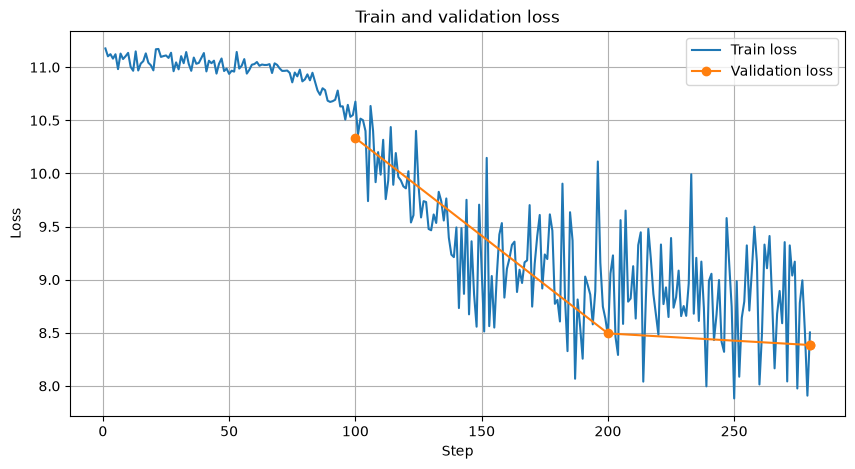

In [9]:
plot_train_eval_loss(
    "output_dir/gpt2-1b-russian/trainer_state.json"
)